# **Modelado de Sudoku como BILP en Python**

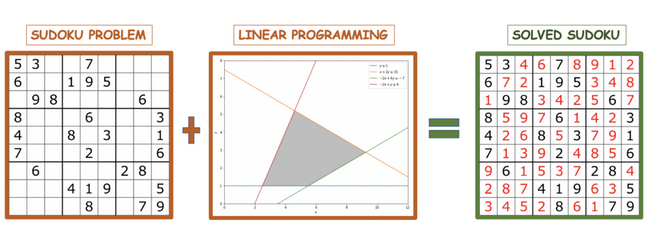


Un Sudoku de $9 \times 9$ es un problema de satisfacción de restricciones donde el objetivo es completar las celdas vacías respetando tres reglas críticas: cada número del $1$ al $9$ debe aparecer exactamente una vez en cada **fila**, cada **columna** y cada **subcuadrícula** de $3 \times 3$.

**IMPLEMENTACIÓN EN PYTHON**

In [ ]:
import time
import random
import pulp as plp
import matplotlib.pyplot as plt

import os

### Funciones para comparar métodos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Banco de pruebas

In [ ]:
def banco_pruebas():
    banco = {
        "Fácil": [],
        "Moderado": [],
        "Difícil": [],
        "Extremadamente Difícil": []
    }
    # NIVEL FÁCIL (Agregar 10 matrices completas)
    #  1
    banco["Fácil"].append([
        [5, 3, 0, 0, 7, 0, 0, 0, 0],
        [6, 0, 0, 1, 9, 5, 0, 0, 0],
        [0, 9, 8, 0, 0, 0, 0, 6, 0],
        [8, 0, 0, 0, 6, 0, 0, 0, 3],
        [4, 0, 0, 8, 0, 3, 0, 0, 1],
        [7, 0, 0, 0, 2, 0, 0, 0, 6],
        [0, 6, 0, 0, 0, 0, 2, 8, 0],
        [0, 0, 0, 4, 1, 9, 0, 0, 5],
        [0, 0, 0, 0, 8, 0, 0, 7, 9]
    ])
    #  2
    banco["Fácil"].append([
        [0, 0, 0, 2, 6, 0, 7, 0, 1],
        [6, 8, 0, 0, 7, 0, 0, 9, 0],
        [1, 9, 0, 0, 0, 4, 5, 0, 0],
        [8, 2, 0, 1, 0, 0, 0, 4, 0],
        [0, 0, 4, 6, 0, 2, 9, 0, 0],
        [0, 5, 0, 0, 0, 3, 0, 2, 8],
        [0, 0, 9, 3, 0, 0, 0, 7, 4],
        [0, 4, 0, 0, 5, 0, 0, 3, 6],
        [7, 0, 3, 0, 1, 8, 0, 0, 0]
    ])
    #  3
    banco["Fácil"].append([
        [0, 0, 0, 2, 6, 0, 7, 0, 1],
        [6, 8, 0, 0, 7, 0, 0, 9, 0],
        [1, 9, 0, 0, 0, 4, 5, 0, 0],
        [8, 2, 0, 1, 0, 0, 0, 4, 0],
        [0, 0, 4, 6, 0, 2, 9, 0, 0],
        [0, 5, 0, 0, 0, 3, 0, 2, 8],
        [0, 0, 9, 3, 0, 0, 0, 7, 4],
        [0, 4, 0, 0, 5, 0, 0, 3, 6],
        [7, 0, 3, 0, 1, 8, 0, 0, 0]
    ])
    #  4
    banco["Fácil"].append([
        [0, 4, 0, 0, 2, 0, 0, 0, 0],
        [5, 0, 0, 7, 0, 0, 0, 0, 0],
        [7, 0, 0, 0, 4, 0, 3, 0, 2],
        [0, 7, 1, 6, 3, 0, 0, 0, 0],
        [0, 0, 9, 0, 7, 4, 0, 3, 6],
        [6, 3, 0, 2, 5, 0, 0, 0, 0],
        [1, 8, 0, 0, 0, 0, 0, 9, 3],
        [4, 0, 7, 0, 0, 8, 5, 6, 1],
        [0, 0, 3, 0, 0, 2, 8, 7, 0]
    ])
    #  5
    banco["Fácil"].append([
        [0, 0, 0, 1, 9, 0, 0, 6, 0],
        [4, 0, 0, 0, 0, 2, 0, 7, 0],
        [0, 2, 0, 6, 0, 0, 3, 8, 5],
        [0, 0, 6, 0, 2, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 3, 1, 2, 6],
        [0, 0, 3, 0, 0, 0, 5, 9, 7],
        [8, 0, 0, 0, 0, 1, 0, 0, 9],
        [0, 4, 0, 7, 5, 9, 6, 0, 0],
        [0, 0, 9, 0, 4, 8, 7, 1, 0]
    ])
    #  6
    banco["Fácil"].append([
        [0, 0, 0, 6, 2, 4, 0, 7, 3],
        [4, 0, 0, 0, 3, 0, 0, 5, 6],
        [0, 7, 0, 8, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 6, 0, 3, 0, 2],
        [8, 0, 9, 7, 4, 0, 6, 0, 0],
        [0, 0, 1, 0, 8, 3, 7, 0, 0],
        [3, 9, 0, 0, 0, 0, 1, 0, 8],
        [0, 0, 7, 0, 0, 0, 2, 4, 0],
        [0, 4, 0, 0, 9, 8, 0, 0, 0]
    ])
    #  7
    banco["Fácil"].append([
        [9, 6, 1, 0, 4, 3, 0, 0, 2],
        [7, 0, 3, 0, 8, 5, 9, 4, 1],
        [0, 4, 5, 9, 2, 1, 0, 0, 0],
        [3, 9, 0, 1, 0, 0, 0, 0, 5],
        [1, 0, 4, 0, 9, 2, 3, 6, 8],
        [5, 0, 2, 4, 3, 0, 0, 0, 7],
        [4, 3, 7, 8, 0, 9, 2, 0, 0],
        [0, 1, 0, 2, 5, 0, 8, 3, 0],
        [0, 5, 8, 3, 0, 4, 7, 0, 0]
    ])
    #  8
    banco["Fácil"].append([
        [0, 0, 6, 7, 0, 2, 8, 9, 5],
        [0, 0, 0, 5, 0, 0, 0, 6, 3],
        [5, 0, 0, 0, 3, 0, 2, 0, 7],
        [0, 6, 9, 0, 0, 0, 0, 4, 0],
        [3, 0, 8, 0, 0, 0, 0, 7, 6],
        [0, 1, 0, 0, 5, 8, 0, 3, 0],
        [6, 0, 0, 2, 0, 7, 0, 0, 0],
        [0, 4, 0, 0, 0, 3, 6, 0, 0],
        [0, 2, 3, 4, 0, 5, 0, 8, 1]
    ])

    #  9
    banco["Fácil"].append([
        [4, 0, 1, 0, 7, 0, 2, 3, 0],
        [0, 3, 0, 5, 2, 0, 4, 6, 1],
        [0, 8, 0, 0, 3, 0, 5, 0, 7],
        [0, 0, 0, 0, 0, 0, 9, 0, 0],
        [0, 6, 7, 1, 0, 2, 3, 0, 0],
        [0, 4, 2, 9, 0, 0, 0, 0, 6],
        [6, 7, 0, 0, 0, 3, 0, 0, 0],
        [0, 2, 0, 7, 4, 5, 0, 0, 0],
        [5, 0, 0, 0, 0, 0, 7, 4, 0]
    ])
    #  10
    banco["Fácil"].append([
        [3, 0, 0, 0, 8, 0, 4, 0, 0],
        [0, 0, 8, 0, 0, 4, 0, 1, 0],
        [4, 7, 0, 0, 9, 0, 0, 0, 0],
        [0, 5, 0, 8, 2, 1, 9, 0, 0],
        [0, 0, 9, 0, 0, 7, 3, 0, 0],
        [0, 2, 4, 0, 3, 9, 7, 0, 0],
        [0, 1, 0, 0, 4, 0, 0, 7, 5],
        [0, 0, 0, 0, 5, 0, 1, 2, 3],
        [0, 0, 7, 0, 0, 6, 8, 0, 4]
    ])


    # NIVEL MODERADO
    #1
    banco["Moderado"].append([
        [0, 3, 0, 1, 0, 0, 9, 7, 0],
        [0, 0, 0, 0, 4, 0, 3, 0, 0],
        [0, 0, 2, 8, 0, 0, 0, 4, 0],
        [3, 0, 0, 0, 0, 5, 0, 0, 0],
        [0, 8, 0, 7, 0, 0, 0, 0, 5],
        [0, 0, 0, 0, 1, 0, 8, 9, 4],
        [9, 0, 0, 0, 0, 0, 0, 6, 0],
        [8, 0, 0, 0, 0, 0, 0, 0, 2],
        [1, 4, 0, 0, 0, 0, 0, 0, 0]
    ])
    #2
    banco["Moderado"].append([
        [0, 8, 0, 0, 0, 0, 0, 5, 6],
        [0, 0, 0, 9, 0, 0, 0, 0, 8],
        [0, 6, 0, 8, 4, 0, 7, 2, 0],
        [0, 0, 0, 0, 7, 9, 0, 0, 0],
        [0, 7, 6, 5, 0, 0, 0, 0, 0],
        [0, 4, 0, 0, 0, 0, 5, 0, 1],
        [1, 0, 0, 0, 6, 0, 0, 0, 0],
        [3, 5, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 2, 7, 0, 3, 0]
    ])
    #3
    banco["Moderado"].append([
        [0, 0, 0, 0, 7, 3, 0, 4, 0],
        [0, 3, 2, 5, 0, 0, 0, 7, 0],
        [0, 0, 0, 0, 9, 0, 0, 0, 0],
        [0, 0, 8, 1, 0, 0, 0, 6, 5],
        [9, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 4, 0, 0, 3, 0, 0, 0, 0],
        [0, 9, 0, 0, 0, 4, 6, 0, 0],
        [0, 2, 0, 0, 0, 1, 0, 8, 0],
        [0, 0, 0, 9, 0, 8, 0, 0, 0]
    ])
    #4
    banco["Moderado"].append([
        [0, 0, 0, 0, 0, 6, 0, 5, 2],
        [9, 0, 0, 0, 0, 1, 0, 0, 7],
        [0, 0, 0, 8, 0, 0, 0, 0, 0],
        [0, 2, 4, 0, 0, 0, 8, 0, 0],
        [0, 0, 1, 0, 5, 0, 0, 7, 0],
        [0, 9, 0, 4, 0, 0, 0, 0, 5],
        [0, 0, 0, 0, 6, 5, 0, 1, 0],
        [0, 0, 0, 0, 0, 2, 4, 3, 0],
        [7, 0, 0, 0, 8, 0, 0, 0, 0]
    ])
    #5
    banco["Moderado"].append([
        [1, 6, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 5, 0],
        [8, 3, 0, 0, 1, 4, 0, 2, 0],
        [0, 0, 0, 0, 7, 0, 9, 0, 4],
        [0, 0, 0, 0, 0, 0, 0, 3, 5],
        [3, 0, 0, 0, 0, 6, 0, 0, 0],
        [0, 0, 0, 0, 0, 8, 0, 9, 0],
        [0, 0, 7, 0, 0, 2, 6, 0, 0],
        [6, 0, 0, 0, 0, 9, 0, 1, 3]
    ])
    #6
    banco["Moderado"].append([###
        [0, 4, 6, 0, 0, 0, 0, 2, 0],
        [0, 7, 0, 2, 9, 8, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 8, 0, 7, 0, 6, 0, 0],
        [3, 0, 0, 0, 0, 0, 0, 0, 7],
        [0, 0, 9, 0, 4, 0, 5, 3, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 9, 6, 3, 0, 7, 0],
        [0, 8, 0, 0, 0, 0, 4, 1, 0]
    ])
    #7
    banco["Moderado"].append([
        [0, 0, 0, 9, 0, 3, 0, 4, 0],
        [0, 3, 6, 0, 0, 0, 0, 0, 2],
        [0, 0, 0, 0, 4, 0, 0, 0, 0],
        [0, 0, 9, 7, 0, 2, 0, 0, 0],
        [0, 7, 0, 0, 0, 0, 0, 9, 0],
        [0, 0, 0, 1, 0, 8, 6, 0, 0],
        [0, 0, 0, 0, 7, 0, 0, 0, 0],
        [9, 0, 0, 0, 0, 0, 4, 7, 0],
        [0, 4, 0, 2, 0, 9, 0, 0, 0]
    ])
    #8
    banco["Moderado"].append([
        [3, 0, 0, 0, 4, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 6, 0, 0, 7],
        [0, 0, 4, 0, 0, 0, 5, 0, 0],
        [0, 0, 8, 0, 0, 0, 9, 0, 0],
        [0, 4, 0, 0, 0, 0, 0, 6, 0],
        [0, 0, 3, 0, 0, 0, 8, 0, 0],
        [0, 0, 6, 0, 0, 0, 4, 0, 0],
        [8, 0, 0, 5, 0, 0, 0, 0, 0],
        [0, 2, 0, 0, 7, 0, 0, 0, 9]
    ])
    #9
    banco["Moderado"].append([
        [0, 0, 0, 0, 0, 4, 0, 7, 0],
        [0, 2, 0, 8, 0, 0, 0, 0, 5],
        [0, 0, 6, 0, 9, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 9, 0],
        [0, 0, 4, 0, 6, 0, 2, 0, 0],
        [0, 8, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 3, 0, 6, 0, 0],
        [9, 0, 0, 0, 0, 7, 0, 4, 0],
        [0, 7, 0, 4, 0, 0, 0, 0, 0]
    ])

    #10
    banco["Moderado"].append([
        [0, 6, 0, 0, 4, 0, 8, 0, 0],
        [0, 0, 0, 0, 0, 6, 0, 0, 4],
        [0, 0, 5, 0, 0, 0, 9, 0, 0],
        [0, 0, 4, 0, 0, 0, 5, 0, 0],
        [0, 7, 0, 0, 0, 0, 0, 2, 0],
        [0, 0, 9, 0, 0, 0, 4, 0, 0],
        [0, 0, 6, 0, 0, 0, 7, 0, 0],
        [5, 0, 0, 2, 0, 0, 0, 0, 0],
        [0, 0, 8, 0, 7, 0, 0, 9, 0]
    ])



    # NIVEL DIFÍCIL
    #1
    banco["Difícil"].append([
        [0, 0, 0, 0, 0, 8, 0, 0, 6],
        [4, 0, 2, 9, 6, 0, 8, 0, 0],
        [6, 7, 0, 0, 0, 0, 0, 4, 0],
        [7, 0, 0, 5, 0, 0, 0, 9, 0],
        [0, 4, 0, 0, 0, 3, 0, 0, 7],
        [0, 3, 0, 8, 1, 0, 0, 6, 0],
        [0, 0, 5, 0, 0, 0, 0, 0, 2],
        [0, 0, 4, 0, 0, 0, 0, 0, 0],
        [3, 0, 0, 0, 0, 0, 0, 0, 1]
    ])
    #2
    banco["Difícil"].append([
        [0, 9, 0, 0, 0, 7, 0, 0, 0],
        [2, 0, 0, 0, 0, 0, 9, 0, 8],
        [0, 0, 6, 0, 4, 0, 2, 1, 0],
        [0, 0, 0, 0, 1, 0, 7, 5, 0],
        [0, 0, 0, 0, 3, 9, 0, 0, 0],
        [0, 0, 0, 2, 0, 8, 6, 0, 0],
        [8, 0, 4, 0, 0, 0, 0, 7, 0],
        [0, 0, 9, 0, 8, 0, 0, 0, 0],
        [0, 6, 3, 0, 0, 0, 1, 0, 0]


        ])
    #3
    banco["Difícil"].append([
        [0, 3, 4, 2, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 8],
        [8, 0, 0, 1, 0, 0, 0, 0, 3],
        [0, 0, 2, 0, 4, 5, 0, 0, 1],
        [0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 7, 3, 0, 2, 0, 0, 4],
        [1, 0, 6, 0, 0, 0, 4, 0, 0],
        [0, 0, 3, 0, 0, 0, 0, 8, 2],
        [5, 0, 0, 0, 0, 4, 9, 0, 7]
    ])
    #4
    banco["Difícil"].append([
        [0, 0, 0, 5, 0, 0, 0, 4, 0],
        [0, 0, 0, 3, 0, 9, 0, 0, 8],
        [0, 0, 6, 0, 0, 0, 2, 0, 0],
        [7, 9, 0, 0, 0, 0, 0, 3, 1],
        [1, 5, 0, 0, 0, 7, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 5, 0, 0],
        [6, 0, 7, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 7, 4, 0, 6, 0],
        [3, 0, 0, 0, 0, 2, 0, 7, 0]
    ])
    #5
    banco["Difícil"].append([###
        [0, 7, 0, 2, 0, 6, 0, 8, 0],
        [0, 0, 1, 0, 0, 5, 0, 6, 0],
        [4, 0, 0, 0, 0, 0, 3, 0, 0],
        [0, 0, 0, 0, 0, 9, 0, 0, 0],
        [0, 0, 0, 8, 0, 0, 0, 0, 0],
        [1, 6, 8, 0, 0, 0, 0, 7, 0],
        [5, 0, 0, 0, 9, 2, 0, 4, 0],
        [2, 0, 0, 7, 0, 8, 9, 0, 6],
        [0, 0, 0, 4, 0, 0, 7, 0, 0]
    ])
    #6
    banco["Difícil"].append([
        [0, 0, 0, 0, 0, 2, 5, 0, 0],
        [0, 0, 0, 0, 6, 0, 0, 0, 9],
        [7, 0, 0, 9, 4, 0, 0, 6, 0],
        [0, 0, 8, 1, 9, 0, 0, 0, 0],
        [0, 0, 5, 0, 0, 0, 7, 0, 0],
        [0, 0, 0, 0, 2, 7, 8, 0, 0],
        [0, 5, 0, 0, 1, 9, 0, 0, 6],
        [6, 0, 0, 0, 7, 0, 0, 0, 0],
        [0, 0, 9, 2, 0, 0, 0, 0, 0]
    ])
    #7
    banco["Difícil"].append([
        [0, 0, 0, 0, 0, 0, 4, 0, 9],
        [0, 0, 0, 5, 0, 0, 0, 0, 0],
        [0, 0, 7, 0, 4, 9, 0, 0, 5],
        [0, 0, 4, 0, 0, 6, 8, 0, 0],
        [2, 0, 0, 0, 8, 0, 0, 0, 6],
        [0, 0, 6, 7, 0, 0, 3, 0, 0],
        [9, 0, 0, 6, 3, 0, 2, 0, 0],
        [0, 0, 0, 0, 0, 4, 0, 0, 0],
        [6, 0, 5, 0, 0, 0, 0, 0, 0]
    ])
    #8
    banco["Difícil"].append([
        [9, 0, 0, 2, 0, 7, 0, 0, 0],
        [0, 0, 0, 0, 8, 0, 0, 0, 1],
        [0, 3, 0, 0, 0, 0, 9, 0, 0],
        [0, 0, 9, 0, 5, 0, 0, 7, 0],
        [7, 5, 0, 0, 0, 0, 0, 6, 8],
        [0, 6, 0, 0, 1, 0, 4, 0, 0],
        [0, 0, 8, 0, 0, 0, 0, 2, 0],
        [4, 0, 0, 0, 6, 0, 0, 0, 0],
        [0, 0, 0, 8, 0, 4, 0, 0, 5]
    ])
    #9
    banco["Difícil"].append([
        [0, 0, 0, 0, 0, 0, 6, 8, 0],
        [9, 0, 0, 0, 8, 0, 0, 3, 0],
        [0, 8, 0, 6, 0, 3, 0, 0, 0],
        [0, 9, 0, 0, 0, 0, 0, 2, 0],
        [0, 0, 5, 0, 0, 0, 3, 0, 0],
        [0, 2, 0, 0, 0, 0, 0, 4, 0],
        [0, 0, 0, 9, 0, 7, 0, 6, 0],
        [0, 6, 0, 0, 2, 0, 0, 0, 4],
        [0, 7, 8, 0, 0, 0, 0, 0, 0]
    ])

    #10
    banco["Difícil"].append([
        [0, 0, 0, 0, 5, 0, 0, 6, 2],
        [0, 0, 0, 2, 0, 7, 0, 0, 0],
        [0, 0, 2, 0, 0, 0, 9, 0, 0],
        [0, 0, 0, 0, 0, 9, 0, 0, 0],
        [0, 0, 5, 0, 7, 0, 3, 0, 0],
        [0, 0, 0, 8, 0, 0, 0, 0, 0],
        [0, 0, 8, 0, 0, 0, 4, 0, 0],
        [0, 0, 0, 7, 0, 3, 0, 0, 0],
        [6, 3, 0, 0, 8, 0, 0, 0, 0]
    ])



    # NIVEL EXTREMADAMENTE DIFÍCIL
    #1
    banco["Extremadamente Difícil"].append([
        [0, 4, 0, 0, 0, 0, 2, 0, 0],
        [0, 1, 7, 5, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 3, 0, 0, 0, 0],
        [4, 0, 0, 0, 0, 8, 0, 9, 3],
        [6, 0, 0, 0, 0, 0, 0, 0, 4],
        [0, 3, 0, 0, 7, 1, 0, 8, 0],
        [8, 0, 0, 0, 9, 0, 0, 3, 0],
        [0, 5, 0, 0, 0, 0, 0, 7, 0],
        [0, 0, 0, 0, 2, 0, 6, 0, 0]
    ])
    #2
    banco["Extremadamente Difícil"].append([
        [0, 6, 0, 0, 5, 0, 7, 0, 2],
        [0, 0, 0, 0, 0, 7, 3, 5, 0],
        [8, 0, 0, 0, 2, 0, 0, 0, 0],
        [2, 0, 0, 6, 0, 0, 0, 4, 0],
        [9, 0, 7, 0, 0, 2, 0, 0, 0],
        [6, 0, 0, 1, 8, 0, 0, 0, 0],
        [0, 0, 9, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 4, 2, 0],
        [4, 0, 0, 0, 0, 0, 0, 1, 9]
    ])
    #3
    banco["Extremadamente Difícil"].append([
        [0, 0, 7, 0, 0, 0, 0, 1, 0],
        [0, 5, 0, 4, 0, 0, 0, 0, 7],
        [8, 4, 0, 0, 0, 0, 0, 0, 6],
        [0, 0, 2, 5, 0, 3, 0, 0, 0],
        [0, 9, 0, 0, 0, 0, 2, 0, 0],
        [3, 7, 1, 0, 0, 0, 0, 5, 0],
        [7, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 6, 0, 0, 0, 4, 0, 0, 8],
        [0, 2, 4, 0, 0, 8, 0, 9, 0]
    ])
    #4
    banco["Extremadamente Difícil"].append([
        [0, 0, 4, 0, 0, 0, 5, 8, 0],
        [0, 8, 0, 6, 0, 0, 0, 0, 0],
        [0, 3, 0, 0, 0, 5, 0, 0, 9],
        [0, 0, 0, 0, 0, 0, 7, 0, 0],
        [0, 0, 0, 3, 0, 0, 0, 0, 0],
        [0, 9, 0, 0, 0, 7, 0, 0, 4],
        [5, 0, 0, 0, 0, 0, 0, 7, 0],
        [0, 0, 0, 8, 0, 4, 0, 5, 0],
        [0, 1, 0, 0, 0, 0, 8, 0, 0]
    ])
    #5
    banco["Extremadamente Difícil"].append([
        [0, 0, 8, 0, 0, 0, 0, 4, 0],
        [0, 0, 0, 5, 0, 9, 0, 0, 0],
        [6, 0, 0, 0, 0, 0, 7, 0, 0],
        [0, 0, 0, 0, 7, 0, 0, 0, 2],
        [0, 0, 4, 0, 0, 0, 6, 0, 0],
        [7, 0, 0, 0, 2, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 8],
        [0, 0, 0, 8, 0, 4, 0, 0, 0],
        [0, 6, 0, 0, 0, 0, 5, 0, 0]
    ])
    #6
    banco["Extremadamente Difícil"].append([
        [0, 0, 0, 0, 8, 0, 0, 0, 5],
        [0, 6, 0, 0, 0, 0, 0, 7, 0],
        [0, 0, 5, 0, 0, 3, 0, 0, 0],
        [0, 0, 0, 4, 0, 0, 0, 8, 0],
        [0, 0, 2, 0, 0, 0, 5, 0, 0],
        [0, 8, 0, 0, 0, 7, 0, 0, 0],
        [0, 0, 0, 7, 0, 0, 3, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 5, 0],
        [7, 0, 0, 0, 4, 0, 0, 0, 0]
    ])
    #7
    banco["Extremadamente Difícil"].append([##
        [8, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 3, 6, 0, 0, 0, 0, 0],
        [0, 7, 0, 0, 9, 0, 2, 0, 0],
        [0, 5, 0, 0, 0, 7, 0, 0, 0],
        [0, 0, 0, 0, 4, 5, 7, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 3, 0],
        [5, 0, 1, 0, 0, 0, 0, 6, 8],
        [0, 0, 8, 5, 0, 0, 0, 1, 0],
        [0, 9, 0, 0, 0, 0, 4, 0, 0]
    ])
    #8
    banco["Extremadamente Difícil"].append([
        [0, 0, 0, 8, 0, 1, 0, 3, 4],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [5, 0, 0, 0, 9, 0, 8, 1, 0],
        [0, 0, 0, 0, 4, 8, 0, 0, 0],
        [9, 0, 2, 7, 0, 0, 0, 0, 0],
        [7, 6, 0, 0, 0, 9, 3, 0, 0],
        [0, 0, 0, 0, 2, 0, 0, 4, 0],
        [4, 0, 0, 0, 3, 7, 9, 0, 0],
        [0, 0, 6, 0, 0, 0, 0, 2, 0]
    ])
    #9
    banco["Extremadamente Difícil"].append([
        [0, 0, 0, 6, 0, 0, 0, 7, 2],
        [0, 8, 4, 0, 9, 0, 0, 0, 6],
        [0, 5, 0, 0, 0, 2, 8, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 3, 1, 0, 5, 0, 0],
        [1, 0, 0, 0, 7, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 2, 0],
        [3, 0, 9, 5, 4, 0, 0, 0, 0],
        [6, 0, 5, 0, 0, 0, 0, 0, 0]
    ])
    #10
    banco["Extremadamente Difícil"].append([
        [3, 0, 0, 0, 0, 2, 0, 0, 5],
        [0, 0, 0, 0, 5, 0, 4, 0, 0],
        [0, 0, 9, 0, 8, 0, 1, 0, 2],
        [0, 0, 3, 0, 0, 0, 0, 7, 0],
        [0, 0, 4, 6, 0, 0, 0, 0, 0],
        [0, 8, 0, 0, 0, 7, 2, 9, 0],
        [0, 3, 0, 5, 4, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1, 6, 0, 0],
        [0, 0, 0, 0, 9, 0, 0, 0, 0]
    ])

    return banco

# **Formulación del Problema (BILP)**



Restricciones del Sudoku

* Cada celda debe rellenarse con un único valor entre 1 y 9.

*  Cada fila debe contener cada número del 1 al 9 exactamente una vez.

*  Cada columna debe contener cada número del 1 al 9 exactamente una vez.

*  Cada región de 3x3 (subcuadrícula), comenzando desde la esquina superior izquierda, debe contener cada número del 1 al 9 exactamente una vez.

In [ ]:
def restricciones_sudoku(prob, vars_cuadricula, filas, columnas, regiones, valores):
    # Restricción para asegurar que solo se asigne un valor a cada celda
    for fila in filas:
        for col in columnas:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([vars_cuadricula[fila][col][valor] for valor in valores]),
                                        sense=plp.LpConstraintEQ, rhs=1, name=f"restriccion_suma_{fila}_{col}"))

    # Restricción para asegurar que los valores del 1 al 9 se usen solo una vez por fila
    for fila in filas:
        for valor in valores:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([vars_cuadricula[fila][col][valor]*valor for col in columnas]),
                                        sense=plp.LpConstraintEQ, rhs=valor, name=f"restriccion_unica_fila_{fila}_{valor}"))

    # Restricción para asegurar que los valores del 1 al 9 se usen solo una vez por columna
    for col in columnas:
        for valor in valores:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([vars_cuadricula[fila][col][valor]*valor for fila in filas]),
                                        sense=plp.LpConstraintEQ, rhs=valor, name=f"restriccion_unica_col_{col}_{valor}"))

    # Restricción para asegurar que los valores del 1 al 9 se usen solo una vez por región (subcuadrícula de 3x3)
    for region in regiones:
        region_fila = int(region / 3)
        region_col  = int(region % 3)

        for valor in valores:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([vars_cuadricula[region_fila*3+fila][region_col*3+col][valor]*valor for col in range(0,3) for fila in range(0,3)]),
                                        sense=plp.LpConstraintEQ, rhs=valor, name=f"restriccion_unica_region_{region}_{valor}"))


Restricciones diagonales

* Cada diagonal debe contener cada número del 1 al 9 exactamente una vez.

In [ ]:
def restricciones_diagonales_sudoku(prob, vars_cuadricula, filas, columnas, valores):
        # Restricción de esquina superior izquierda a esquina inferior derecha: los números del 1 al 9 no deben repetirse
        for valor in valores:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([vars_cuadricula[fila][fila][valor]*valor for fila in filas]),
                                            sense=plp.LpConstraintEQ, rhs=valor, name=f"restriccion_unica_diag1_{valor}"))

        # Restricción de esquina superior derecha a esquina inferior izquierda: los números del 1 al 9 no deben repetirse
        for valor in valores:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([vars_cuadricula[fila][len(filas)-fila-1][valor]*valor for fila in filas]),
                                            sense=plp.LpConstraintEQ, rhs=valor, name=f"restriccion_unica_diag2_{valor}"))

Las pistas como restricciones

* Incluir las celdas ya completadas (pistas) como restricciones para el problema.

In [ ]:
def restricciones_valores_iniciales(prob, sudoku_entrada, vars_cuadricula, filas, columnas, valores):
    for fila in filas:
        for col in columnas:
            if(sudoku_entrada[fila][col] != 0):
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([vars_cuadricula[fila][col][valor]*valor for valor in valores]),
                                                    sense=plp.LpConstraintEQ,
                                                    rhs=sudoku_entrada[fila][col],
                                                    name=f"restriccion_inicial_{fila}_{col}"))


# SIMULACIÓN Y MEDICIÓN DEL SUDOKU ESTÁNDAR

In [ ]:
def resolver_sudoku(sudoku_entrada, diagonal=False):
    # Crear el problema de programación lineal
    prob = plp.LpProblem("Sudoku_Solver", plp.LpMinimize)

    filas = range(0, 9)
    columnas = range(0, 9)
    cuadriculas = range(0, 9)
    valores = range(1, 10)

    # Variables de decisión binarias
    grid_vars = plp.LpVariable.dicts("Celdas", (filas, columnas, valores), cat='Binary')

    # Función objetivo trivial (problema de factibilidad)
    prob += 0

    # Cargar restricciones usando tus funciones en español
    restricciones_sudoku(prob, grid_vars, filas, columnas, cuadriculas, valores)
    restricciones_valores_iniciales(prob, sudoku_entrada, grid_vars, filas, columnas, valores)

    # Agregar restricciones diagonales si la bandera está en True
    if diagonal:
        restricciones_diagonales_sudoku(prob, grid_vars, filas, columnas, valores)

    # Resolver el problema ocultando los logs del solver
    prob.solve(plp.PULP_CBC_CMD(msg=False))

    # Retornar el estado del problema para validación
    return plp.LpStatus[prob.status]

In [ ]:
#BANCO DE PRUEBAS
banco = banco_pruebas()
reporte_final = {}

for nivel, instancias in banco.items():
    tiempos_nivel = []

    for idx, sudoku_instancia in enumerate(instancias):

        # Medición estricta del tiempo que toma resolverlo
        start_time = time.perf_counter()
        estado = resolver_sudoku(sudoku_instancia, diagonal=False) # Cambiar a True si es Sudoku X
        end_time = time.perf_counter()

        # Solo guardamos el tiempo si la solución fue óptima (exitosa)
        if estado == "Optimal":
            tiempo_ejecucion = end_time - start_time
            tiempos_nivel.append(tiempo_ejecucion)
        else:
            print(f"Advertencia: El Sudoku {idx+1} del nivel {nivel} no se pudo resolver (Estado: {estado})")

    # Guardar resultados y calcular el promedio del nivel
    if tiempos_nivel:
        promedio = sum(tiempos_nivel) / len(tiempos_nivel)
    else:
        promedio = 0.0

    reporte_final[nivel] = {
        "tiempos": tiempos_nivel,
        "promedio": promedio
    }

print("RESUMEN DE TIEMPOS PROMEDIO")

for nivel, datos in reporte_final.items():
    print(f"Nivel {nivel:<22} | Tiempo Promedio: {datos['promedio']:.5f} seg")


RESUMEN DE TIEMPOS PROMEDIO
Nivel Fácil                  | Tiempo Promedio: 0.14110 seg
Nivel Moderado               | Tiempo Promedio: 0.13849 seg
Nivel Difícil                | Tiempo Promedio: 0.10148 seg
Nivel Extremadamente Difícil | Tiempo Promedio: 0.10027 seg


In [ ]:
# Código para guardar tus datos desde Python
with open("tiempos_python.txt", "w") as f:
    for nivel, data in reporte_final.items():
        corridas = data["tiempos"]
        corridas_str = ",".join(map(str, corridas))
        f.write(f"{nivel}:{corridas_str}\n")

# **Comparación Python y Julia**

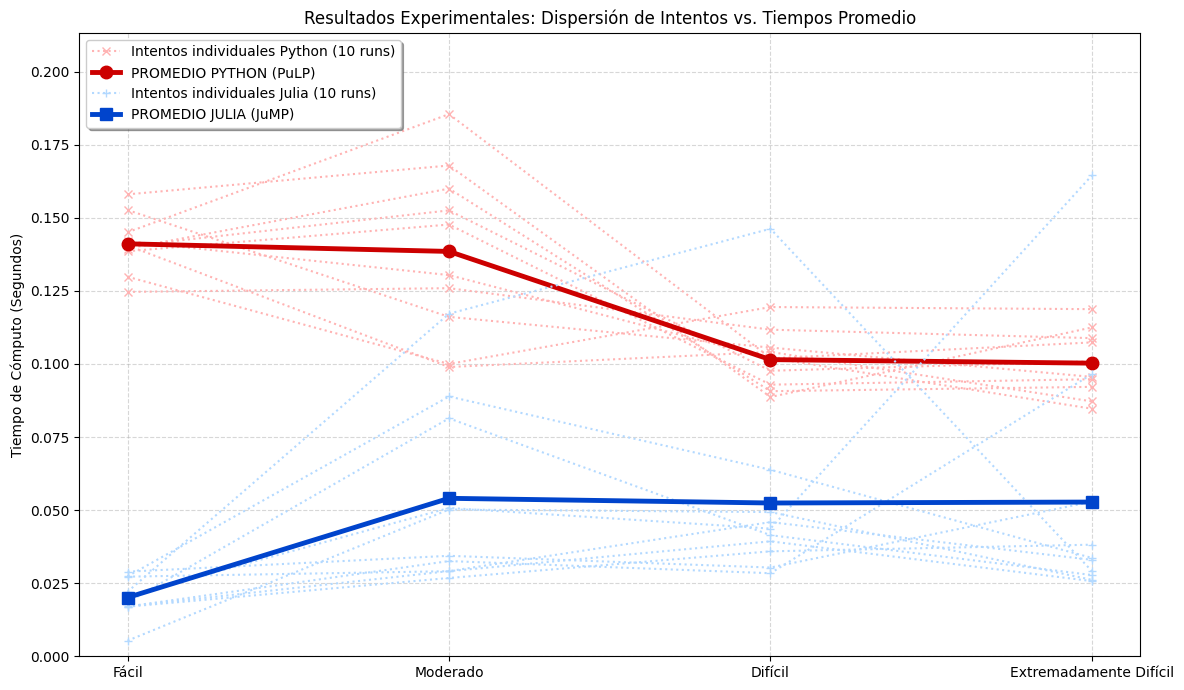

In [ ]:
carpeta_drive = "/content/drive/MyDrive/Investigación/"

ruta_python = os.path.join("/content", "tiempos_python.txt")
ruta_julia = os.path.join(carpeta_drive, "tiempos_julia.txt")

# 2. FUNCIÓN PARA TRANSFORMAR EL TXT AL FORMATO DE TU GRÁFICA
def parsear_archivo_tiempos(ruta_archivo):
    """
    Lee el archivo TXT y lo transforma en la estructura que tu gráfica necesita:
    { "Nivel": {"promedio": X, "tiempos": [t1, t2, ...]} }
    """
    reporte = {}
    if not os.path.exists(ruta_archivo):
        print(f"Alerta: No se encontró el archivo en {ruta_archivo}")
        return None

    with open(ruta_archivo, "r") as f:
        for linea in f:
            if ":" in linea:
                nivel, valores_str = linea.strip().split(":")
                # Limpiamos espacios y quitamos la palabra "Diagonal" si Julia la agregó
                # para que coincida exactamente con las etiquetas de Python
                nivel_limpio = nivel.replace("Diagonal ", "").strip()

                # Convertimos la lista de strings de las 10 corridas a números flotantes
                tiempos_run = [float(x) for x in valores_str.split(",")]

                # Calculamos el promedio de esos 10 intentos
                promedio = sum(tiempos_run) / len(tiempos_run)

                reporte[nivel_limpio] = {
                    "promedio": promedio,
                    "tiempos": tiempos_run
                }
    return reporte

# Cargamos los datos de ambos mundos
reporte_python = parsear_archivo_tiempos(ruta_python)
reporte_julia = parsear_archivo_tiempos(ruta_julia)


# GRÁFICA
if reporte_python and reporte_julia:
    # Definimos el orden estricto de las dificultades
    dificultades = ["Fácil", "Moderado", "Difícil", "Extremadamente Difícil"]
    # Extraemos los promedios en el orden correcto
    promedios_python = [reporte_python[n]["promedio"] for n in dificultades]
    promedios_julia = [reporte_julia[n]["promedio"] for n in dificultades]
    max_runs_py = min(len(reporte_python[nivel]["tiempos"]) for nivel in dificultades)
    max_runs_ju = min(len(reporte_julia[nivel]["tiempos"]) for nivel in dificultades)


    #GRAFICO
    plt.figure(figsize=(12, 7))
    #python
    for i in range(max_runs_py):
        valores_py = [reporte_python[nivel]["tiempos"][i] for nivel in dificultades]
        if i == 0:
            plt.plot(dificultades, valores_py, color='#ffb3b3', linestyle=':', marker='x',
             label=f'Intentos individuales Python ({max_runs_py} runs)')
        else:
            plt.plot(dificultades, valores_py, color='#ffb3b3', linestyle=':', marker='x')
    # Promedio Python
    plt.plot(dificultades, promedios_python, color='#cc0000', marker='o', markersize=9,
             linewidth=3.5, label='PROMEDIO PYTHON (PuLP)')
    #Julia
    for i in range(max_runs_ju):
        valores_ju = [reporte_julia[nivel]["tiempos"][i] for nivel in dificultades]
        if i == 0:
            plt.plot(dificultades, valores_ju, color='#b3d9ff', linestyle=':', marker='+',
                      label=f'Intentos individuales Julia ({max_runs_ju} runs)')
        else:
            plt.plot(dificultades, valores_ju, color='#b3d9ff', linestyle=':', marker='+')

    # Promedio Julia
    plt.plot(dificultades, promedios_julia, color='#0044cc', marker='s', markersize=8,
             linewidth=3.5, label='PROMEDIO JULIA (JuMP)')



    plt.ylabel('Tiempo de Cómputo (Segundos)')
    plt.title('Resultados Experimentales: Dispersión de Intentos vs. Tiempos Promedio')
    max_py = max([max(reporte_python[n]["tiempos"]) for n in dificultades])
    max_ju = max([max(reporte_julia[n]["tiempos"]) for n in dificultades])
    max_tiempo_absoluto = max(max_py, max_ju)
    plt.ylim(0, max_tiempo_absoluto * 1.15)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True, facecolor='white')
    plt.tight_layout()
    plt.show()


# **SUDOKU DIAGONAL**

## Simulación

In [ ]:
# 1. Definimos el tablero para el Sudoku Diagonal proporcionado
diagonal_sudoku = [
    [0, 3, 0, 2, 7, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [8, 0, 0, 0, 0, 0, 0, 0, 0],
    [5, 1, 0, 0, 0, 0, 0, 8, 4],
    [4, 0, 0, 5, 9, 0, 0, 7, 0],
    [2, 9, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 5],
    [0, 0, 6, 3, 0, 8, 0, 0, 7],
    [0, 0, 0, 0, 0, 0, 3, 0, 0]
]

# Lista para almacenar los tiempos de cada iteración exitosa
tiempos_corridas = []

for i in range(10):
    # Medición de alta precisión para cada iteración
    start_time = time.perf_counter()
    estado = resolver_sudoku(sudoku_entrada=diagonal_sudoku, diagonal=True)
    end_time = time.perf_counter()

    tiempo_ejecucion = end_time - start_time

    if estado == "Optimal":
        tiempos_corridas.append(tiempo_ejecucion)
        print(f" Corrida {i+1:02d}: exitosa en {tiempo_ejecucion:.6f} seg")
    else:
        print(f"Corrida {i+1:02d}: No se pudo resolver. Estado: {estado}")


if tiempos_corridas:
    tiempo_total = sum(tiempos_corridas)
    tiempo_promedio = tiempo_total / len(tiempos_corridas)

    print("")
    print(f" Tiempo Promedio:     {tiempo_promedio:.6f} segundos")
else:
    print(" No se pudieron calcular promedios debido a fallos (ej. Infeasible).")


 Corrida 01: exitosa en 0.112084 seg
 Corrida 02: exitosa en 0.105179 seg
 Corrida 03: exitosa en 0.115479 seg
 Corrida 04: exitosa en 0.108326 seg
 Corrida 05: exitosa en 0.121467 seg
 Corrida 06: exitosa en 0.107029 seg
 Corrida 07: exitosa en 0.110338 seg
 Corrida 08: exitosa en 0.107276 seg
 Corrida 09: exitosa en 0.106196 seg
 Corrida 10: exitosa en 0.208897 seg

 Tiempo Promedio:     0.120227 segundos


# **¿Qué pasa cuando el sudoku no tiene ninguna pista?**

In [ ]:
# tablero  vacío
sudoku_vacio = [[0 for _ in range(9)] for _ in range(9)]

# Lista para almacenar los tiempos de cada iteración exitosa
tiempos_corridas = []

for i in range(10):
    # Medición
    start_time = time.perf_counter()
    estado = resolver_sudoku(sudoku_entrada=sudoku_vacio, diagonal=False)
    end_time = time.perf_counter()
    tiempo_ejecucion = end_time - start_time

    if estado == "Optimal":
        tiempos_corridas.append(tiempo_ejecucion)
        print(f" Corrida {i+1:02d}: exitosa en {tiempo_ejecucion:.6f} seg")
    else:
        print(f"Corrida {i+1:02d}: No se pudo resolver. Estado: {estado}")

if tiempos_corridas:
    tiempo_total = sum(tiempos_corridas)
    tiempo_promedio = tiempo_total / len(tiempos_corridas)

    print(" ")
    print(f" Tiempo Promedio:     {tiempo_promedio:.6f} segundos")
else:
    print(" No se pudieron calcular promedios porque todas las corridas fallaron.")


 Corrida 01: exitosa en 0.123314 seg
 Corrida 02: exitosa en 0.120156 seg
 Corrida 03: exitosa en 0.117211 seg
 Corrida 04: exitosa en 0.119809 seg
 Corrida 05: exitosa en 0.125806 seg
 Corrida 06: exitosa en 0.118521 seg
 Corrida 07: exitosa en 0.114439 seg
 Corrida 08: exitosa en 0.116354 seg
 Corrida 09: exitosa en 0.114921 seg
 Corrida 10: exitosa en 0.115611 seg
 
 Tiempo Promedio:     0.118614 segundos
